In [ ]:
import kagglehub

path = kagglehub.dataset_download("fantacher/neu-metal-surface-defects-data")

print("Path to dataset files:", path)

In [ ]:
import shutil
from pathlib import Path

src_path = Path("/root/.cache/kagglehub/datasets/fantacher/neu-metal-surface-defects-data/versions/1")

dst_path = Path("/content/dataset/neu")

if dst_path.exists():
    shutil.rmtree(dst_path)

shutil.copytree(src_path, dst_path)


In [3]:
from pathlib import Path
import os, cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_root = Path("dataset/neu/NEU Metal Surface Defects Data")
train_dir = data_root / "train"
val_dir   = data_root / "valid"
test_dir  = data_root / "test"

classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
print("Classes:", classes)

Classes: ['Crazing', 'Inclusion', 'Patches', 'Pitted', 'Rolled', 'Scratches']


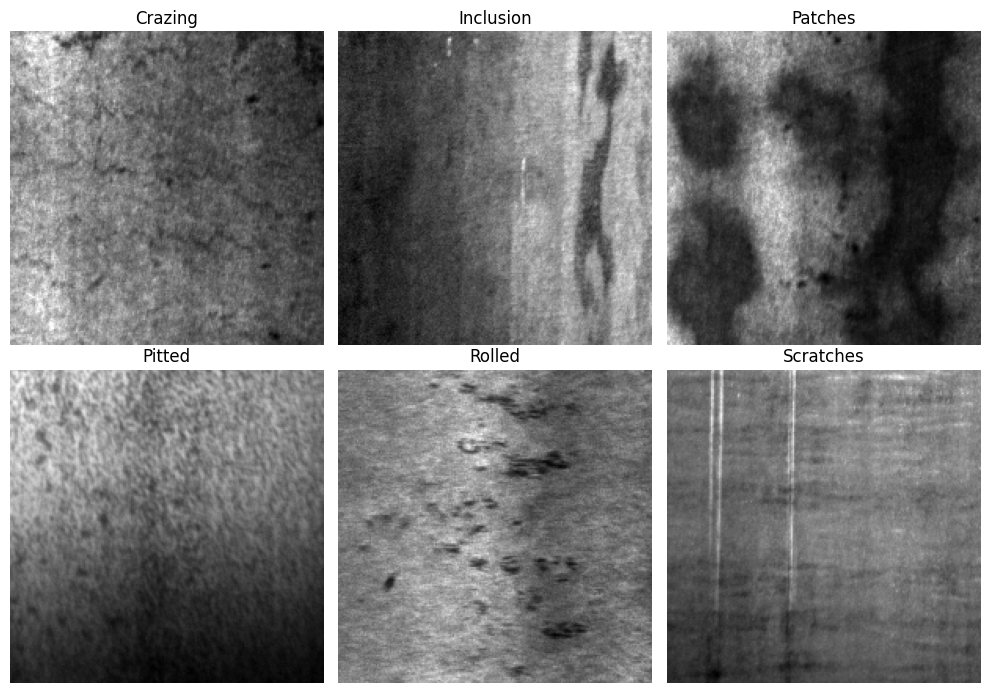

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(10,7))
for ax, cls in zip(axes.ravel(), classes):
    cands = list((train_dir/cls).glob("*.bmp"))
    img = cv2.imread(str(cands[0]), cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap="gray")
    ax.set_title(cls)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [5]:
img_size   = (200, 200)
batch_size = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True
).flow_from_directory(
    str(train_dir),
    target_size=img_size,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=True
)

val_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    str(val_dir),
    target_size=img_size,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=False
)

test_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    str(test_dir),
    target_size=img_size,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=False
)

inv_map = {v: k for k, v in train_gen.class_indices.items()}
print("Class indexes:", train_gen.class_indices)

Found 1656 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Found 72 images belonging to 6 classes.
Class indexes: {'Crazing': 0, 'Inclusion': 1, 'Patches': 2, 'Pitted': 3, 'Rolled': 4, 'Scratches': 5}


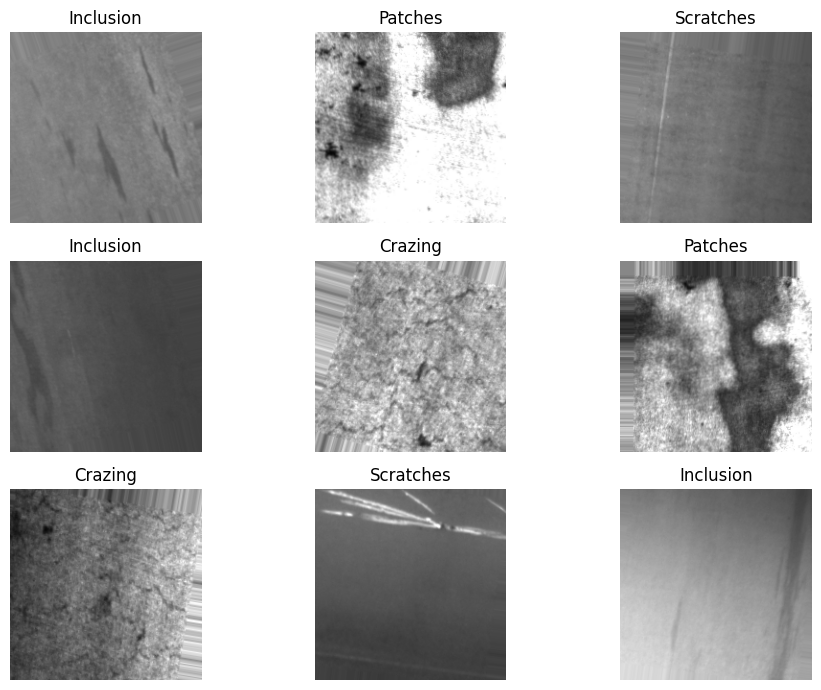

In [6]:
imgs, labs = next(train_gen)

plt.figure(figsize=(10,7))
for i in range(9):
    ax = plt.subplot(3,3,i+1)
    ax.imshow(imgs[i])
    cls_id = int(np.argmax(labs[i]))
    ax.set_title(inv_map[cls_id])
    ax.axis("off")
plt.tight_layout()
plt.show()